# 02 - Carbon-Aware Scheduler

Goal: compare scheduling strategies across multiple real weeks of the HPC trace using synthetic carbon intensity and the energy predictions produced by the selected model from phase 1.

The scheduler model respects:

- job release time, so a job cannot start before it was submitted;
- parallel system capacity, modeled through requested processors;
- job duration;
- a maximum carbon-aware delay window.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS = PROJECT / 'results' / 'scheduler'
sys.path.insert(0, str(PROJECT / 'src'))

print('Project root detected')
print('Results directory:', RESULTS.relative_to(PROJECT))


Project root detected
Results directory: results\scheduler


## Result Generation

Run the energy/carbon model-selection step first. It writes `job_predictions.csv` using the selected validation model. Then run the scheduler:

```bash
python scripts/01_run_carbon_prediction.py --max-rows 60000
python scripts/02_run_scheduler.py --num-weeks 0 --max-jobs 1200 --split all
```


In [2]:
metrics = pd.read_csv(RESULTS / 'scheduler_metrics.csv')
metrics

,policy,scheduled_jobs,skipped_jobs,total_actual_energy_kwh,total_actual_emissions_kg,total_predicted_emissions_kg,avg_wait_h,median_wait_h,p95_wait_h,avg_slowdown,max_processors_used,emissions_delta_vs_fcfs_kg,emissions_reduction_vs_fcfs_pct,avg_wait_delta_vs_fcfs_h
0,fcfs,12000.0,0.0,84836.381528,27364.660871,16187.101160,0.000000,0.000000,0.000000,1.000000,1452.0,0.000000,0.000000,0.000000
1,random,12000.0,0.0,84836.381528,27078.906180,15962.779118,11.744625,11.750139,22.758444,18.924428,761.0,-285.754691,1.044247,11.744625
2,carbon_aware,12000.0,0.0,84836.381528,25965.510150,15135.236288,12.360627,12.477917,20.146389,20.452392,8175.0,-1399.150720,5.112984,12.360627


In [3]:
weekly = pd.read_csv(RESULTS / 'scheduler_weekly_metrics.csv')
carbon_weekly = weekly[weekly['policy'].eq('carbon_aware')]
summary = {
    'weeks': weekly['week_index'].nunique(),
    'jobs_per_policy': int(metrics.loc[metrics['policy'].eq('carbon_aware'), 'scheduled_jobs'].iloc[0]),
    'carbon_aware_reduction_weighted_pct': metrics.loc[metrics['policy'].eq('carbon_aware'), 'emissions_reduction_vs_fcfs_pct'].iloc[0],
    'carbon_aware_reduction_weekly_mean_pct': carbon_weekly['emissions_reduction_vs_fcfs_pct'].mean(),
    'carbon_aware_reduction_weekly_min_pct': carbon_weekly['emissions_reduction_vs_fcfs_pct'].min(),
    'carbon_aware_reduction_weekly_max_pct': carbon_weekly['emissions_reduction_vs_fcfs_pct'].max(),
}
pd.Series(summary).to_frame('value')

,value
weeks,10.000000
jobs_per_policy,12000.000000
carbon_aware_reduction_weighted_pct,5.112984
carbon_aware_reduction_weekly_mean_pct,7.464324
carbon_aware_reduction_weekly_min_pct,3.067069
carbon_aware_reduction_weekly_max_pct,14.405052


## Compared Policies

- `fcfs`: first-come first-served; each job starts as soon as capacity is available.
- `random`: random feasible delay, useful as a simple baseline.
- `carbon_aware`: for each job, searches within the maximum delay window and selects the feasible start time with the lowest average carbon intensity, using predicted energy.

Hardware note: based on the project notes, Marconi-100 is modeled with 980 nodes and 16 processors per node, for a total of 15,680 processors. The PM100 column `num_nodes_req` is treated as requested processors, not as nodes.

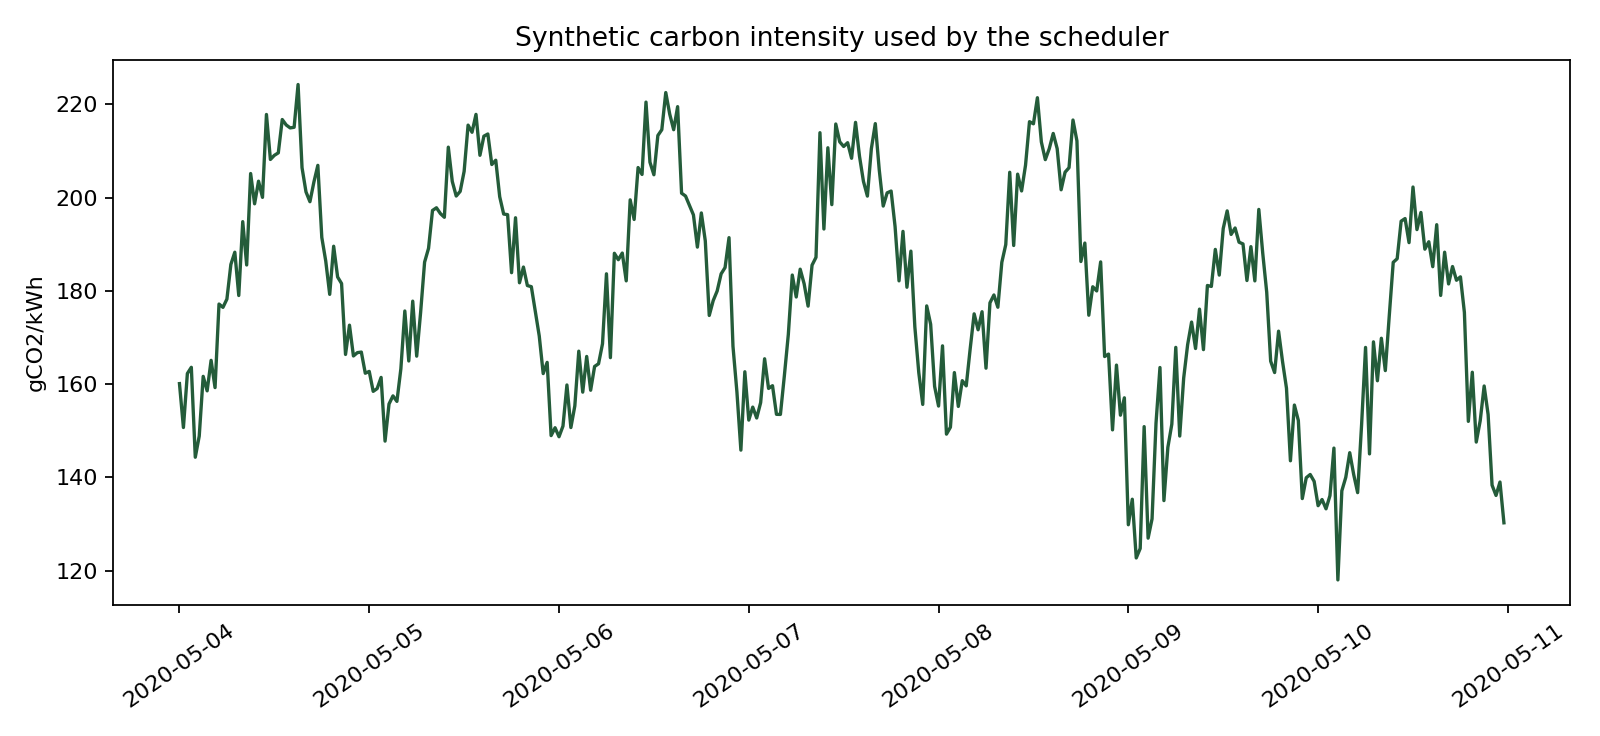

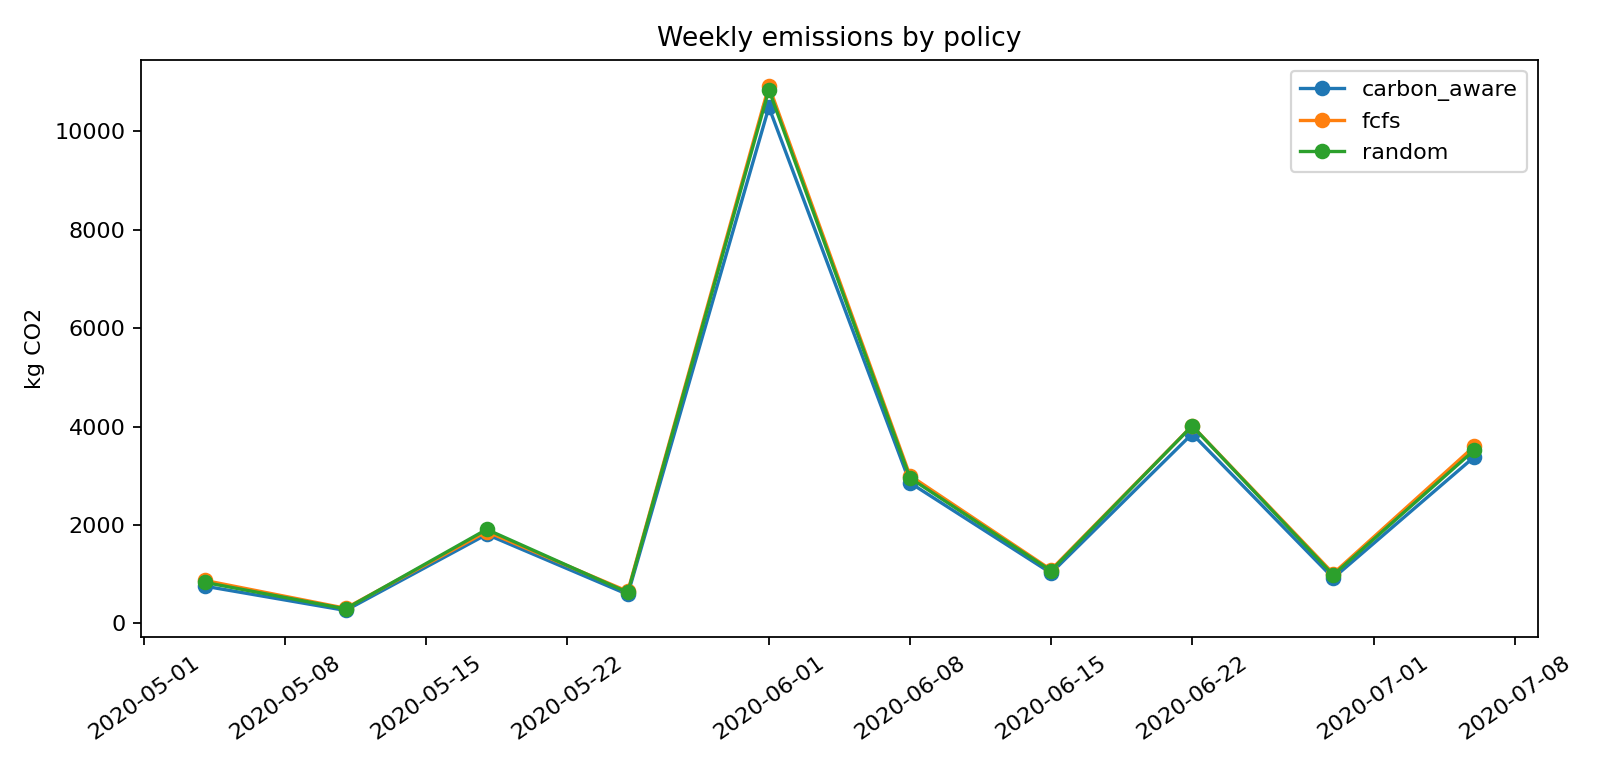

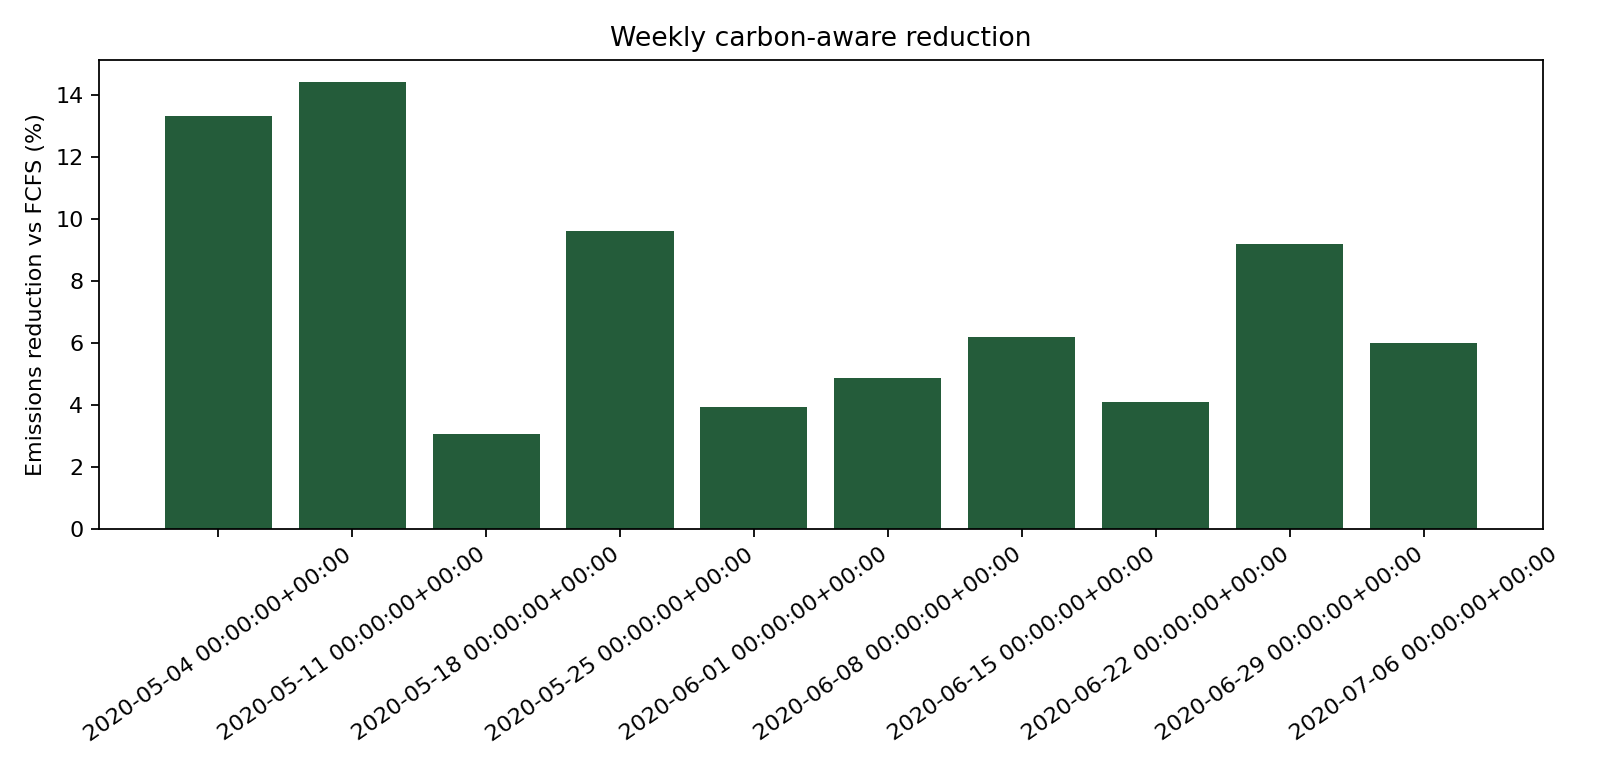

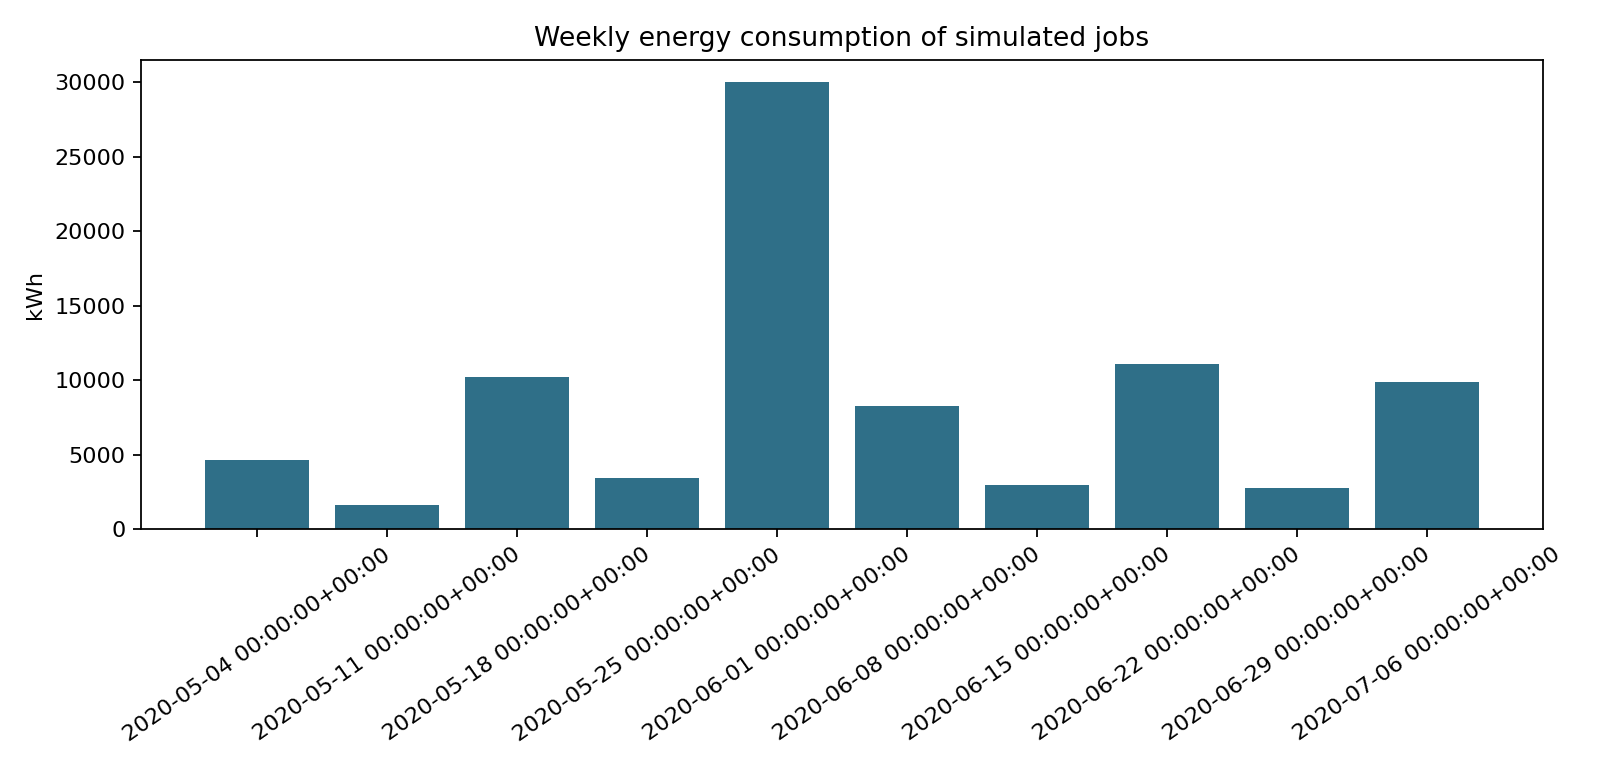

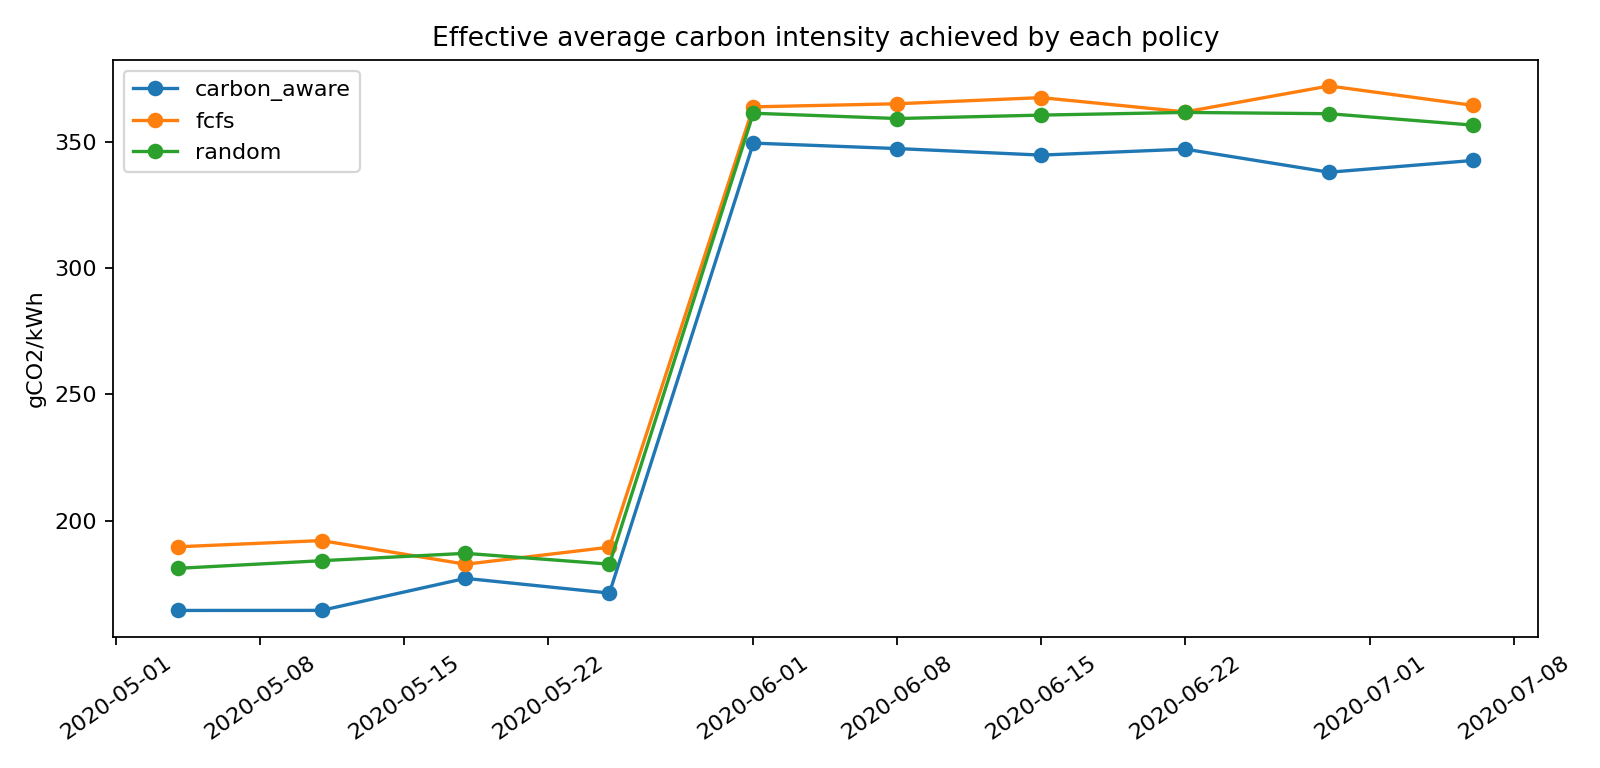

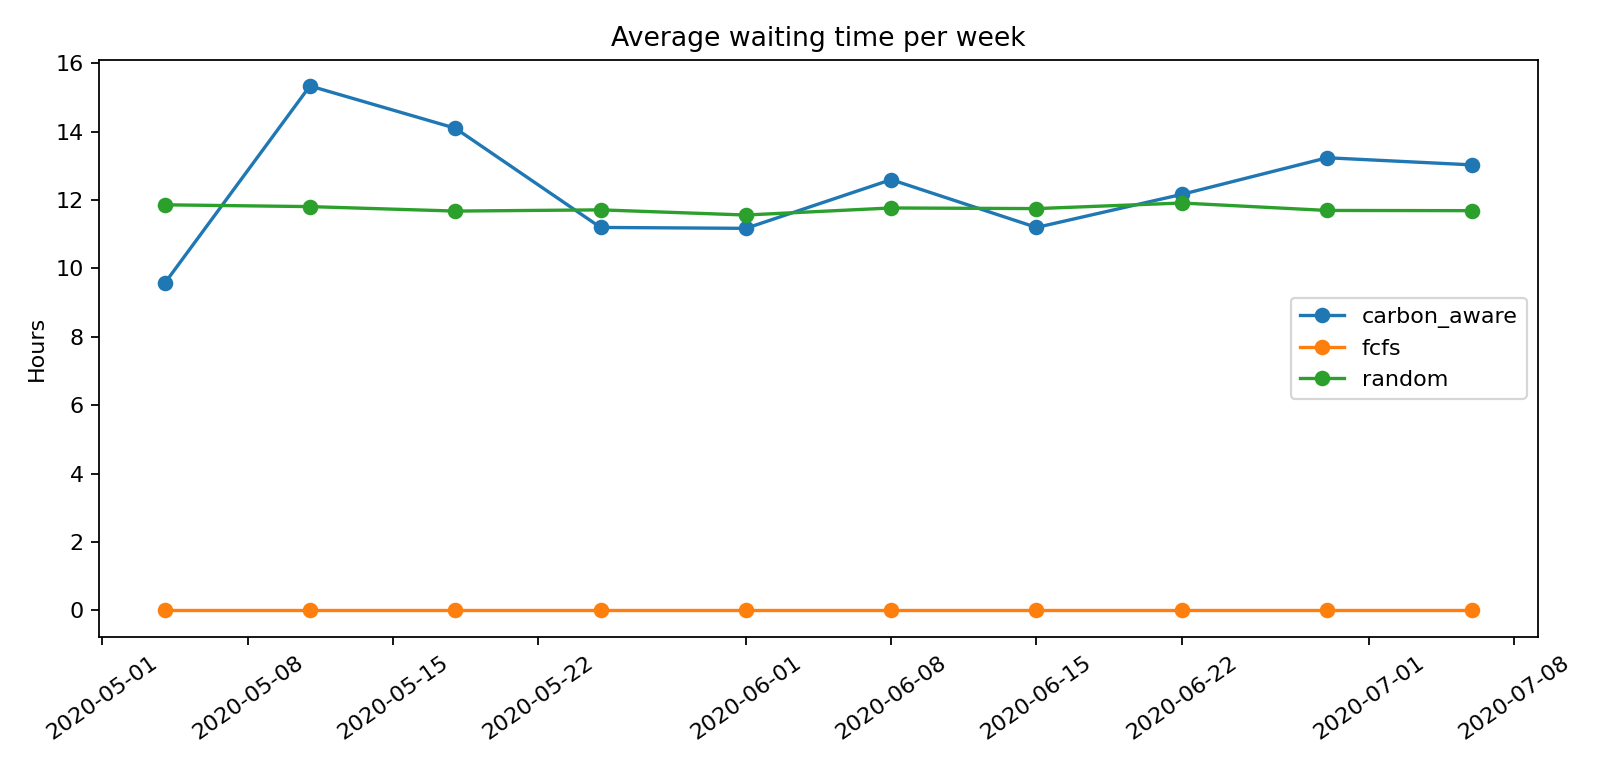

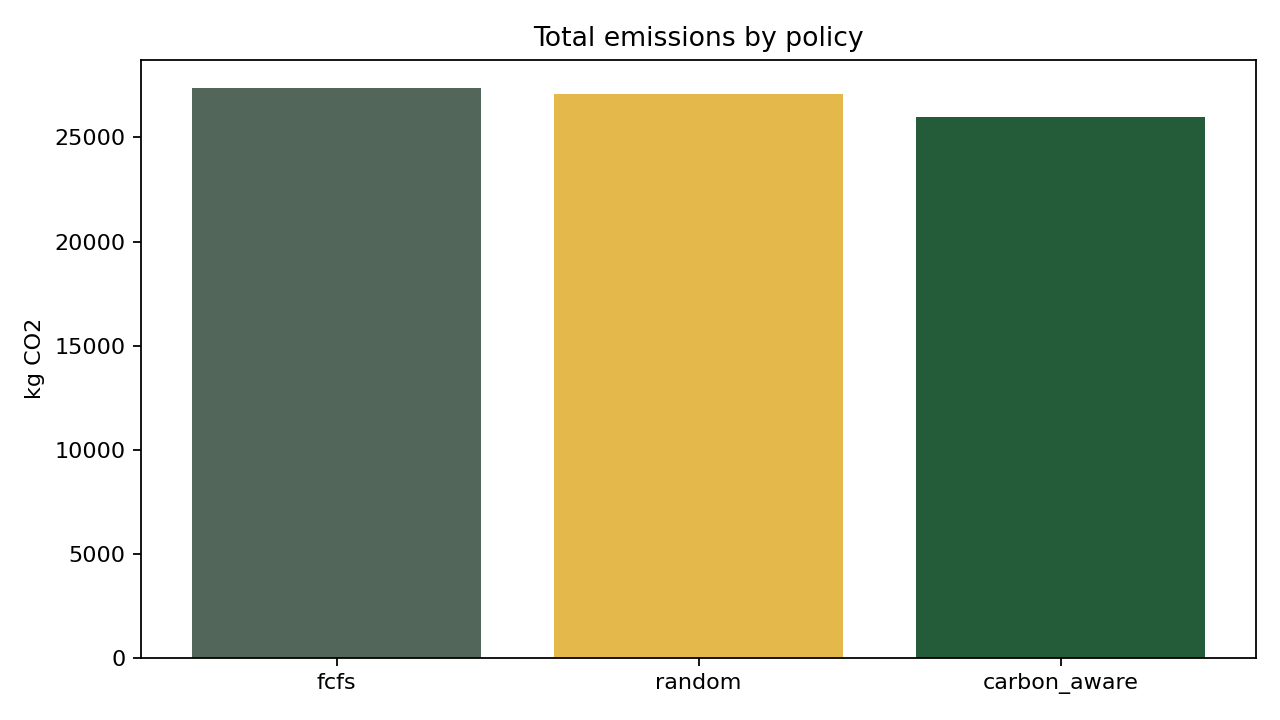

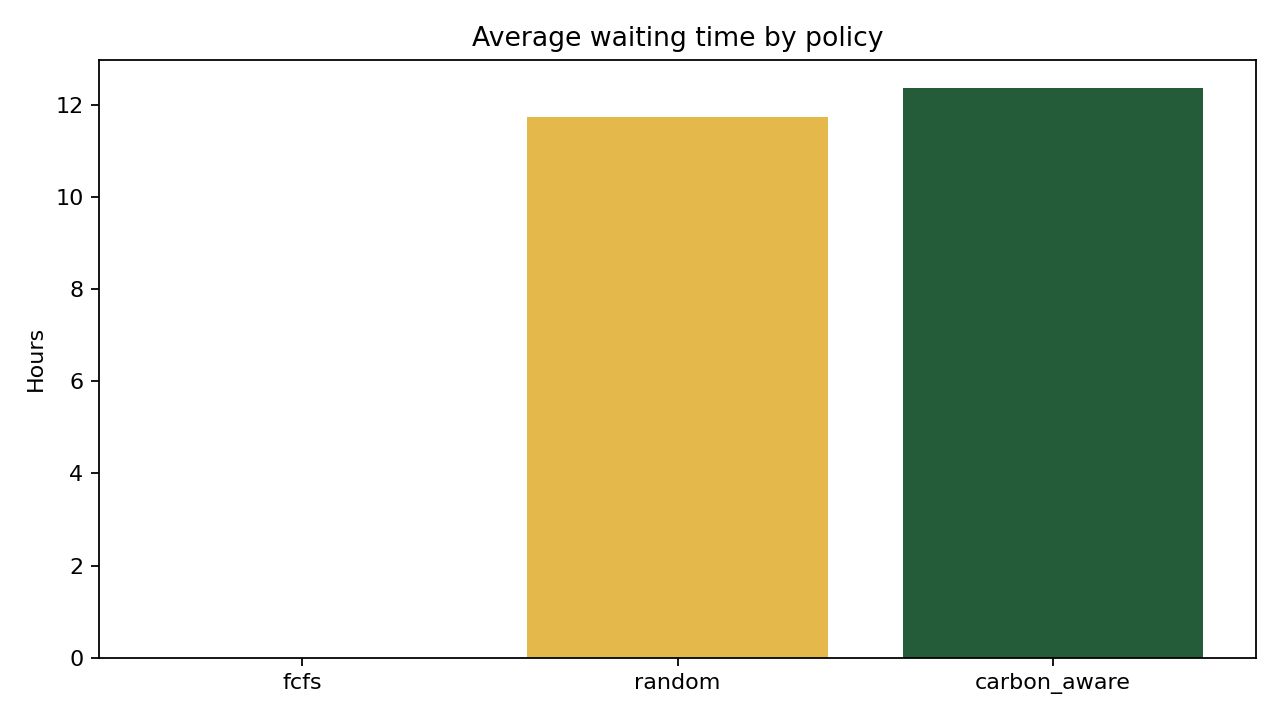

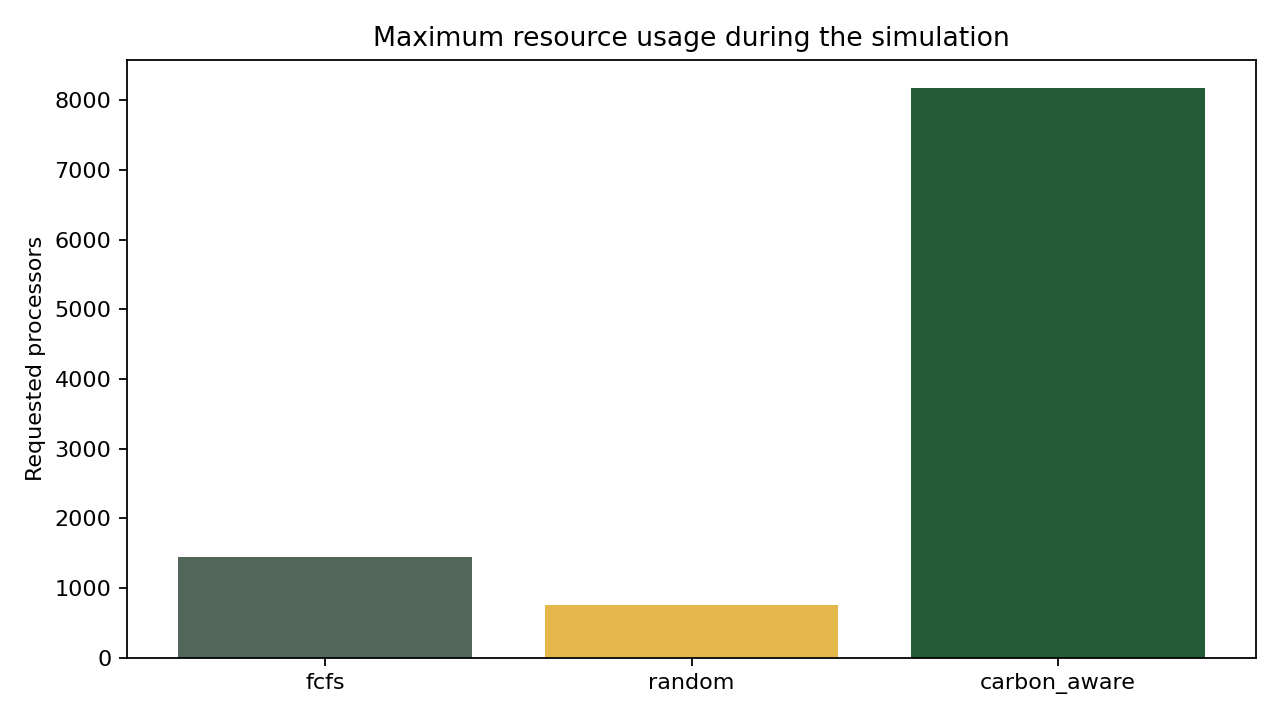

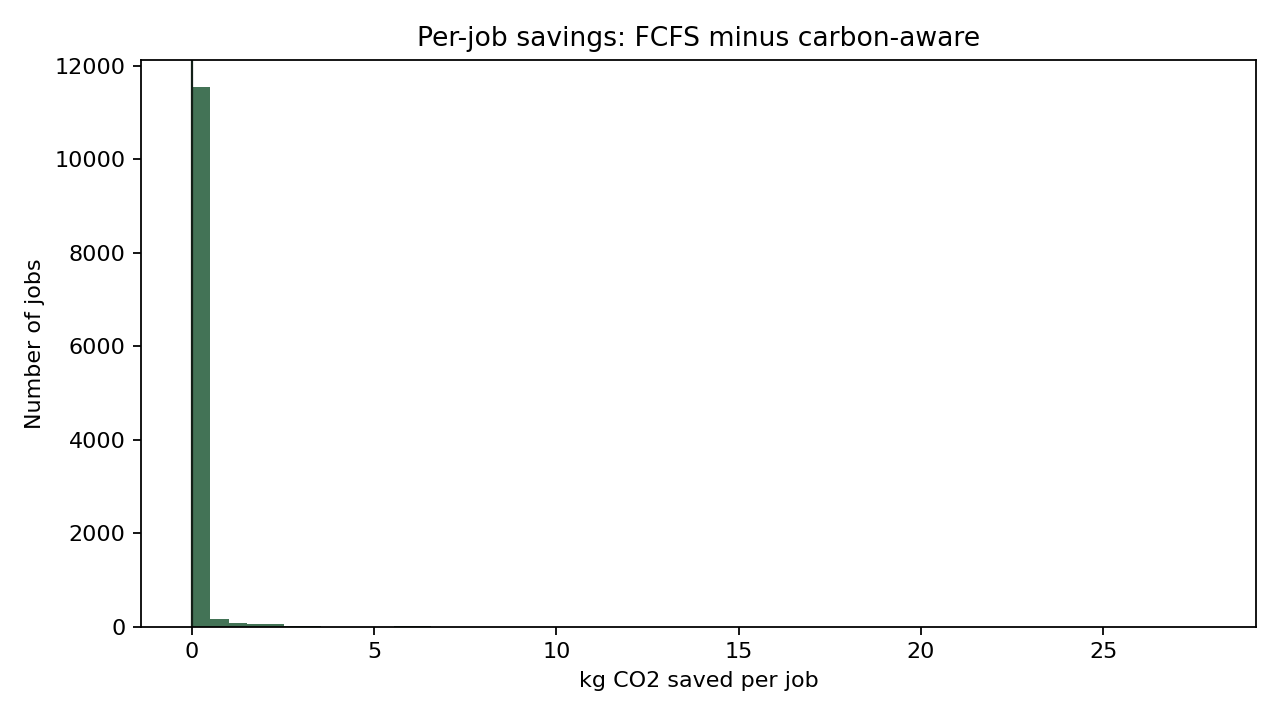

In [4]:
for name in [
    'synthetic_carbon_curve_week.png',
    'scheduler_weekly_emissions.png',
    'scheduler_weekly_reduction_pct.png',
    'scheduler_weekly_energy.png',
    'scheduler_weekly_avg_carbon.png',
    'scheduler_weekly_wait.png',
    'scheduler_emissions_comparison.png',
    'scheduler_wait_comparison.png',
    'scheduler_nodes_usage.png',
    'scheduler_per_job_savings_histogram.png',
]:
    display(Image(filename=str(RESULTS / name)))

## Skipped Job Check

Skipped jobs are reported explicitly by policy and reason, so the simulation remains auditable.

In [5]:
skipped = pd.read_csv(RESULTS / 'skipped_jobs.csv')
if skipped.empty:
    print('No skipped jobs.')
else:
    display(skipped.groupby(['policy', 'reason']).size().reset_index(name='count'))

No skipped jobs.


## Schedule Example

In [6]:
schedule = pd.read_csv(RESULTS / 'schedules.csv')
cols = ['policy', 'job_id', 'submit_time', 'scheduled_start', 'scheduled_end', 'req_nodes', 'wait_h', 'actual_emissions_kg']
schedule[cols].head(20)

,policy,job_id,submit_time,scheduled_start,scheduled_end,req_nodes,wait_h,actual_emissions_kg
0,fcfs,5370710,2020-05-06 06:41:32+00:00,2020-05-06 06:30:00+00:00,2020-05-06 10:30:00+00:00,1,0.0,0.685859
1,fcfs,175694,2020-05-06 06:48:37+00:00,2020-05-06 06:30:00+00:00,2020-05-06 12:00:00+00:00,8,0.0,8.742559
2,fcfs,2214444,2020-05-06 07:04:53+00:00,2020-05-06 07:00:00+00:00,2020-05-06 12:00:00+00:00,13,0.0,7.950694
3,fcfs,2687047,2020-05-06 07:45:12+00:00,2020-05-06 07:30:00+00:00,2020-05-06 13:30:00+00:00,16,0.0,17.711482
4,fcfs,4281751,2020-05-06 07:59:15+00:00,2020-05-06 07:30:00+00:00,2020-05-06 10:00:00+00:00,9,0.0,2.906611
5,fcfs,584948,2020-05-06 08:04:51+00:00,2020-05-06 08:00:00+00:00,2020-05-06 10:00:00+00:00,4,0.0,0.991773
6,fcfs,3192383,2020-05-06 08:12:32+00:00,2020-05-06 08:00:00+00:00,2020-05-06 12:00:00+00:00,1,0.0,0.733017
7,fcfs,3783714,2020-05-06 08:23:13+00:00,2020-05-06 08:00:00+00:00,2020-05-06 18:30:00+00:00,13,0.0,16.668413
8,fcfs,3096661,2020-05-06 08:31:39+00:00,2020-05-06 08:30:00+00:00,2020-05-06 11:00:00+00:00,6,0.0,1.965195
9,fcfs,4678367,2020-05-06 08:43:38+00:00,2020-05-06 08:30:00+00:00,2020-05-06 11:30:00+00:00,1,0.0,0.453507


## Key Message

The carbon-aware scheduler introduces a trade-off: it reduces emissions by choosing lower-carbon-intensity windows, but it increases waiting time. The final run uses predictions from the model selected in phase 1 and evaluates the policies over 10 real weeks, so the result shows both the average improvement and the week-by-week variability.
